# **Configuración inicial**

## **Conección a Drive**

In [1]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##**Rutas de guardado**

In [ ]:
import os

# --- 1. CONFIGURACIÓN DE RUTAS ---
path_origen = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_guardado = "/content/drive/MyDrive/Observatorio/Bases_limpias"

print("🧪 --- INICIANDO DIAGNÓSTICO DE RUTAS ---")

# A. Verificar Carpeta de Origen
if os.path.exists(path_origen):
    print(f"✅ Conexión con ORIGEN exitosa.")
    # Listar las subcarpetas para ver si coinciden con los rangos (90-99, 00-06, etc.)
    subcarpetas = [f for f in os.listdir(path_origen) if os.path.isdir(os.path.join(path_origen, f))]
    print(f"📂 Subcarpetas encontradas: {subcarpetas}")
else:
    print(f"❌ ERROR: No veo la ruta de ORIGEN. Revisa si el Drive está montado.")

# B. Verificar Carpeta de Guardado
if not os.path.exists(path_guardado):
    print(f"⚠️ La carpeta de GUARDADO no existe. Se creará automáticamente al procesar.")
else:
    print(f"✅ Carpeta de GUARDADO lista.")

# C. Muestreo de Archivos (El test real)
# Vamos a intentar ver un archivo de cada década para confirmar los nombres
test_años = [1995, 2005, 2015, 2024]

print("\n🔍 --- MUESTREO DE ARCHIVOS ---")
for anio in test_años:
    # Lógica de carpetas que planteamos
    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    folder_path = os.path.join(path_origen, sub)

    if os.path.exists(folder_path):
        archivos_en_folder = os.listdir(folder_path)
        # Buscamos algo que se parezca al año (ej: '95', '1995', '05')
        match = [f for f in archivos_en_folder if str(anio)[-2:] in f or str(anio) in f]
        if match:
            print(f"✅ Año {anio}: Encontrado como '{match[0]}' en la subcarpeta '{sub}'")
        else:
            print(f"❓ Año {anio}: La carpeta existe, pero no veo el archivo. Archivos ahí: {archivos_en_folder[:3]}...")
    else:
        print(f"❌ Año {anio}: No encuentro la subcarpeta '{sub}'")

🧪 --- INICIANDO DIAGNÓSTICO DE RUTAS ---
✅ Conexión con ORIGEN exitosa.
📂 Subcarpetas encontradas: ['1990-1999', '2000-2006', '2007-2017', '2018-presente']
✅ Carpeta de GUARDADO lista.

🔍 --- MUESTREO DE ARCHIVOS ---
✅ Año 1995: Encontrado como 'empleo1995.dta' en la subcarpeta '1990-1999'
✅ Año 2005: Encontrado como 'empleo2005.dta' en la subcarpeta '2000-2006'
✅ Año 2015: Encontrado como 'empleo2015.dta' en la subcarpeta '2007-2017'
✅ Año 2024: Encontrado como 'empleo2024.dta' en la subcarpeta '2018-presente/Trimestrales'


In [ ]:
import os

# Usamos la ruta que definimos antes
path_guardado = "/content/drive/MyDrive/Observatorio/Bases_limpias"
test_file = os.path.join(path_guardado, "test_permisos.txt")

print(f"📝 Intentando escribir en: {path_guardado}...")

try:
    # 1. Intentar crear un archivo
    with open(test_file, "w") as f:
        f.write("Test de permisos exitoso.")

    # 2. Verificar que se creó
    if os.path.exists(test_file):
        print("✅ TEST DE ESCRITURA EXITOSO: El script puede guardar archivos aquí.")
        # 3. Limpiar (borrar el archivo de test)
        os.remove(test_file)
        print("🧹 Archivo de prueba eliminado correctamente.")
    else:
        print("❌ ERROR: El archivo no se creó. Revisa los permisos de la carpeta.")

except Exception as e:
    print(f"❌ ERROR CRÍTICO DE ESCRITURA: {e}")
    print("\n💡 Tip: Asegúrate de que la carpeta 'Bases_limpias' no sea de 'Solo Lectura' o que tengas espacio en Drive.")

📝 Intentando escribir en: /content/drive/MyDrive/Observatorio/Bases_limpias...
✅ TEST DE ESCRITURA EXITOSO: El script puede guardar archivos aquí.
🧹 Archivo de prueba eliminado correctamente.


#**Mapeo de variables**

In [ ]:
import pandas as pd
import pyreadstat
import os

# --- 1. CONFIGURACIÓN DE RUTAS ---
path_origen = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_guardado = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_excel_mapa = os.path.join(path_guardado, "Mapa_Maestro_1990_2024.xlsx")

# --- 2. DICCIONARIO DE BÚSQUEDA (Esquema + Revisor) ---
var_buscadas = {
    "Genero": ["sexo", "p02"], #Emi
    "Edad": ["edad", "p03"], #Wil
    "Educación": ["nivinst", "p10a", "p10b", "anoinst"], #Wil
    "Estado civil": ["p06", "p07", "civil", "pe13c"],
    "Provincia": ["ciudad", "prov"], #Wil
    "Informal-Afiliación": ["iess", "p05a", "p05b"], # Wilson
    "Etnia": ["p15", "pe14", "pe13"], #Emi
    "Rama-Actividad": ["rama", "rama1", "ciiu"], #Emi
    "Informal-Sector informal": ["peamsiu", "secemp", "SECEMP"], # Wilson
    "Trabajo-Semana-Pasada": ["p20", "trabajo"],
    "Ayuda-Hogar": ["p21", "actayuda"],
    "Establecimiento tiene RUC": ["p49","pe51", "pe49", "pe51"],
    "Horas-Semana-Anterior": ["p24", "hortrasa"],
    "Desea-Mas-Horas": ["p27", "hormas", "ratmeh1"],
    "Ingreso-Laboral": ["ingrl", "ing_lab", "p66", "p59", "p54a"] # p54a/p59 comunes en 90s
}

datos_finales = []

# --- 3. EJECUCIÓN DEL ESCÁNER ---
for anio in range(1990, 2025):
    # Lógica de subcarpetas según diagnóstico exitoso
    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    archivo_nombre = f"empleo{anio}.dta"
    ruta_full = os.path.join(path_origen, sub, archivo_nombre)

    if os.path.exists(ruta_full):
        print(f"🔬 Escaneando {anio}...", end=" ")
        try:
            # Solo metadatos para velocidad
            _, meta = pyreadstat.read_dta(ruta_full, metadataonly=True)
            cols_reales = meta.column_names

            for concepto, posibles in var_buscadas.items():
                # Buscamos coincidencias (case insensitive)
                matches = [c for c in cols_reales if c.lower() in [p.lower() for p in posibles]]

                for m in matches:
                    # Capturamos etiquetas de valor (Stata Labels)
                    dicc = meta.variable_value_labels.get(m, {})
                    etiquetas = " / ".join([f"{k}:{v}" for k, v in dicc.items()]) if dicc else "Sin Etiquetas (Continua)"

                    datos_finales.append({
                        "Año": anio,
                        "Concepto_Analisis": concepto,
                        "Variable_Original_DTA": m,
                        "Etiquetas_Diccionario": etiquetas[:1000] # Evitar celdas gigantes en Excel
                    })
            print("✅")
        except Exception as e:
            print(f"❌ Error: {e}")
    else:
        print(f"⚠️ Año {anio} NO encontrado en ruta.")

# --- 4. EXPORTACIÓN FINAL ---
if datos_finales:
    df_mapa = pd.DataFrame(datos_finales)
    df_mapa.to_excel(ruta_excel_mapa, index=False)
    print(f"\n🔥 ¡MAPA MAESTRO GENERADO! Ubicación: {ruta_excel_mapa}")
else:
    print("\n❌ No se recolectaron datos. Revisa la lógica de búsqueda.")

🔬 Escaneando 1990... ✅
🔬 Escaneando 1991... ✅
🔬 Escaneando 1992... ✅
🔬 Escaneando 1993... ✅
🔬 Escaneando 1994... ✅
🔬 Escaneando 1995... ✅
🔬 Escaneando 1996... ✅
🔬 Escaneando 1997... ✅
🔬 Escaneando 1998... ✅
🔬 Escaneando 1999... ✅
🔬 Escaneando 2000... ✅
🔬 Escaneando 2001... ✅
🔬 Escaneando 2002... ✅
🔬 Escaneando 2003... ✅
🔬 Escaneando 2004... ✅
🔬 Escaneando 2005... ✅
🔬 Escaneando 2006... ✅
🔬 Escaneando 2007... ✅
🔬 Escaneando 2008... ✅
🔬 Escaneando 2009... ✅
🔬 Escaneando 2010... ✅
🔬 Escaneando 2011... ✅
🔬 Escaneando 2012... ✅
🔬 Escaneando 2013... ✅
🔬 Escaneando 2014... ✅
🔬 Escaneando 2015... ✅
🔬 Escaneando 2016... ✅
🔬 Escaneando 2017... ✅
🔬 Escaneando 2018... ✅
🔬 Escaneando 2019... ✅
🔬 Escaneando 2020... ✅
🔬 Escaneando 2021... ✅
🔬 Escaneando 2022... ✅
🔬 Escaneando 2023... ✅
🔬 Escaneando 2024... ✅

🔥 ¡MAPA MAESTRO GENERADO! Ubicación: /content/drive/MyDrive/Observatorio/Bases_limpias/Mapa_Maestro_1990_2024.xlsx


# **Armonización**

## **Informal-Afiliación**
Indica si está afiliado al *IESS*

In [ ]:
import pandas as pd

# 1. Definimos la ruta exacta donde se guardó el mapa
ruta_mapa = "/content/drive/MyDrive/Observatorio/Bases_limpias/Mapa_Maestro_1990_2024.xlsx"

# 2. Cargamos el Excel que generamos hace un momento
df_mapa = pd.read_excel(ruta_mapa)

# 3. Filtramos solo para la variable de interés: Informal-Afiliación
# Nota: Verifica si en tu diccionario usamos 'Afiliación-IESS' o 'Informal-Afiliación'
mapa_afiliacion = df_mapa[df_mapa['Concepto_Analisis'] == 'Informal-Afiliación'].sort_values('Año')

# 4. Desplegamos el resultado para auditar
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 500):
    print("📋 AUDITORÍA DE VARIABLE: AFILIACIÓN AL IESS (1990-2024)")
    print("-" * 100)
    if not mapa_afiliacion.empty:
        print(mapa_afiliacion[['Año', 'Variable_Original_DTA', 'Etiquetas_Diccionario']])
    else:
        print("⚠️ No se encontraron registros. Revisa si el nombre del concepto es 'Afiliación-IESS' o 'Informal-Afiliación' en tu diccionario.")

📋 AUDITORÍA DE VARIABLE: AFILIACIÓN AL IESS (1990-2024)
----------------------------------------------------------------------------------------------------
      Año Variable_Original_DTA  \
4    1990                  iess   
15   1991                  iess   
27   1992                  iess   
40   1993                  iess   
52   1994                  iess   
64   1995                  iess   
76   1996                  iess   
88   1997                  iess   
100  1998                  iess   
112  1999                  iess   
125  2000                  iess   
137  2001                  iess   
151  2002                  iess   
166  2003                  iess   
179  2004                  iess   
193  2005                  iess   
208  2006                  iess   
225  2007                  p05a   
226  2007                  p05b   
245  2008                  p05a   
246  2008                  p05b   
265  2009                  p05a   
266  2009                  p05b   
285

🔄 Procesando 1990 (Estricto)... ✅
🔄 Procesando 1991 (Estricto)... ✅
🔄 Procesando 1992 (Estricto)... ✅
🔄 Procesando 1993 (Estricto)... ✅
🔄 Procesando 1994 (Estricto)... ✅
🔄 Procesando 1995 (Estricto)... ✅
🔄 Procesando 1996 (Estricto)... ✅
🔄 Procesando 1997 (Estricto)... ✅
🔄 Procesando 1998 (Estricto)... ✅
🔄 Procesando 1999 (Estricto)... ✅
🔄 Procesando 2000 (Estricto)... ✅
🔄 Procesando 2001 (Estricto)... ✅
🔄 Procesando 2002 (Estricto)... ✅
🔄 Procesando 2003 (Estricto)... ✅
🔄 Procesando 2004 (Estricto)... ✅
🔄 Procesando 2005 (Estricto)... ✅
🔄 Procesando 2006 (Estricto)... ✅
🔄 Procesando 2007 (Estricto)... ✅
🔄 Procesando 2008 (Estricto)... ✅
🔄 Procesando 2009 (Estricto)... ✅
🔄 Procesando 2010 (Estricto)... ✅
🔄 Procesando 2011 (Estricto)... ✅
🔄 Procesando 2012 (Estricto)... ✅
🔄 Procesando 2013 (Estricto)... ✅
🔄 Procesando 2014 (Estricto)... ✅
🔄 Procesando 2015 (Estricto)... ✅
🔄 Procesando 2016 (Estricto)... ✅
🔄 Procesando 2017 (Estricto)... ✅
🔄 Procesando 2018 (Estricto)... ✅
🔄 Procesando 2

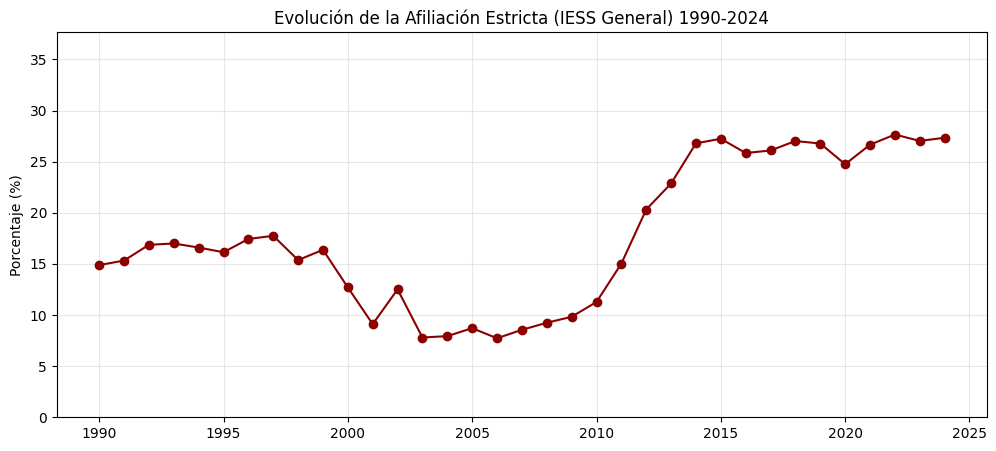


🚀 Master estricto guardado en: /content/drive/MyDrive/Observatorio/Bases_limpias/Master_Afiliacion_Estricta_90_24.dta


In [ ]:
import pandas as pd
import pyreadstat
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURACIÓN DE RUTAS ---
path_base = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_mapa = os.path.join(path_limpias, "Mapa_Maestro_1990_2024.xlsx")

df_mapa = pd.read_excel(ruta_mapa)

def regla_estricta_iess(row, columnas, anio):
    """
    REGLA PEDIDA: Solo IESS General (No Voluntario, No Campesino)
    1: IESS General
    0: Otros Seguros o Ninguno
    """
    if anio <= 2000:
        # En los 90s no se puede separar, asumimos el 'si' como base general
        cods_iess = [1]
    elif 2001 <= anio <= 2006:
        # Según tu auditoría: 2 es IESS General. (3 es Campesino -> va a 0)
        cods_iess = [2]
    else:
        # Según tu auditoría: 1 es IESS General. (2 es Voluntario, 3 es Campesino -> van a 0)
        cods_iess = [1]

    for col in columnas:
        val = row[col]
        if pd.isna(val): continue
        try:
            if int(float(val)) in cods_iess:
                return 1
        except:
            continue
    return 0

# --- 2. PROCESAMIENTO ---
lista_master = []

for anio in range(1990, 2025):
    # Usando los nombres de columna de tu auditoría visual
    info_anio = df_mapa[(df_mapa['Año'] == anio) & (df_mapa['Concepto_Analisis'] == 'Informal-Afiliación')]
    if info_anio.empty: continue

    columnas_dta = [c for c in info_anio['Variable_Original_DTA'].unique() if c.lower() in ['iess', 'p05a']]

    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    ruta_input = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta_input):
        print(f"🔄 Procesando {anio} (Estricto)...", end=" ")

        # Leemos solo IESS General (usualmente p05a o iess)
        df_t, meta = pyreadstat.read_dta(ruta_input, usecols=columnas_dta)

        df_t['iess_estricto'] = df_t.apply(lambda x: regla_estricta_iess(x, columnas_dta, anio), axis=1)
        df_t['anio'] = anio
        df_t['id_persona'] = df_t.index

        # Guardado DTA individual
        ruta_out = os.path.join(path_limpias, "Temporales", f"afilia_estricta_{anio}.dta")
        os.makedirs(os.path.dirname(ruta_out), exist_ok=True)

        pyreadstat.write_dta(df_t[['anio', 'id_persona', 'iess_estricto']], ruta_out,
                             column_labels={'iess_estricto': 'Solo IESS General (1:Si, 0:No)'},
                             variable_value_labels={'iess_estricto': {1: "IESS General", 0: "Otros/No"}})

        lista_master.append(df_t[['anio', 'id_persona', 'iess_estricto']])
        print("✅")

# --- 3. MASTER Y GRÁFICO ---
df_master_final = pd.concat(lista_master, ignore_index=True)
ruta_master = os.path.join(path_limpias, "Master_Afiliacion_Estricta_90_24.dta")
pyreadstat.write_dta(df_master_final, ruta_master)

# Control de %
control = df_master_final.groupby('anio')['iess_estricto'].mean() * 100
}
plt.figure(figsize=(12, 5))
plt.plot(control.index, control, marker='o', color='darkred', label='% IESS General')
plt.title('Evolución de la Afiliación Estricta (IESS General) 1990-2024')
plt.ylabel('Porcentaje (%)')
plt.grid(True, alpha=0.3)
plt.ylim(0, max(control)+10)
plt.show()

print(f"\n🚀 Master estricto guardado en: {ruta_master}")

### **Opción 2 IESS**

🔄 Procesando 1990 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1991 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1992 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1993 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1994 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1995 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1996 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1997 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1998 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 1999 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2000 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2001 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2002 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2003 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2004 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2005 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2006 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2007 (Opción 2: IESS + Militares)... ✅
🔄 Procesando 2008 (Opción 2: IESS + Militares)... ✅
🔄 Procesando

,% Informal/Otros (0),% Formal IESS+Mil (1)
anio,,
1990,85.12,14.88
1991,84.67,15.33
1992,83.13,16.87
1993,83.01,16.99
1994,83.40,16.60
1995,83.86,16.14
1996,82.56,17.44
1997,82.25,17.75
1998,84.63,15.37


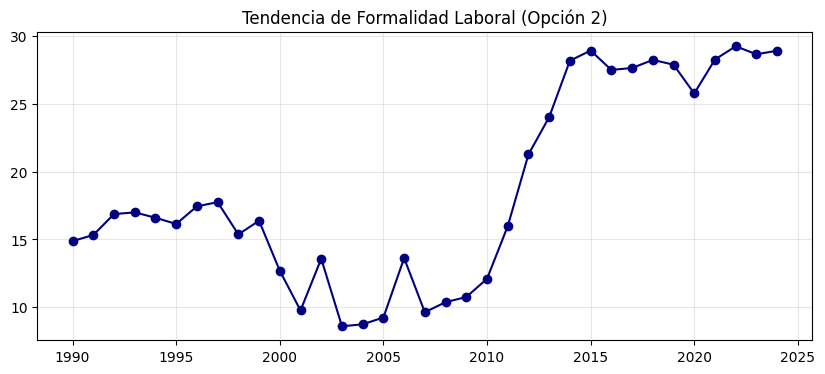


🚀 Master Opción 2 guardado en: /content/drive/MyDrive/Observatorio/Bases_limpias/Master_Afiliacion_Opcion2_90_24.dta


In [ ]:
import pandas as pd
import pyreadstat
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURACIÓN DE RUTAS ---
path_base = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_mapa = os.path.join(path_limpias, "Mapa_Maestro_1990_2024.xlsx")

# Cargar Mapa Maestro
df_mapa = pd.read_excel(ruta_mapa)

def regla_formalidad_opcion2(row, columnas, anio):
    """
    OPCIÓN 2: Formalidad Laboral Civil y Militar
    1: IESS General + ISSFA (Militares) + ISSPOL (Policías)
    0: Seguro Campesino, Voluntario, Privado, Ninguno o Otros.
    """
    if anio <= 2000:
        # En los 90s, el '1' (Sí) es nuestra única base de formalidad
        cods_formal = [1]
    elif 2001 <= anio <= 2006:
        # 2: IESS General, 4: ISSFA/ISSPOL. (3: Campesino va a 0)
        cods_formal = [2, 4]
    else:
        # 1: IESS General, 4: ISSFA/ISSPOL. (2: Voluntario, 3: Campesino van a 0)
        cods_formal = [1, 4]

    for col in columnas:
        val = row[col]
        if pd.isna(val): continue
        try:
            if int(float(val)) in cods_formal:
                return 1
        except:
            continue
    return 0

# --- 2. PROCESAMIENTO ---
lista_master_op2 = []

for anio in range(1990, 2025):
    # Filtro según tu Mapa Maestro
    info_anio = df_mapa[(df_mapa['Año'] == anio) & (df_mapa['Concepto_Analisis'] == 'Informal-Afiliación')]
    if info_anio.empty: continue

    # Variables de interés (p05a suele ser general, p05b suele ser el resto)
    columnas_dta = [c for c in info_anio['Variable_Original_DTA'].unique() if c.lower() in ['iess', 'p05a', 'p05b']]

    # Lógica de subcarpetas
    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    ruta_input = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta_input):
        print(f"🔄 Procesando {anio} (Opción 2: IESS + Militares)...", end=" ")

        # Lectura
        df_t, meta = pyreadstat.read_dta(ruta_input, usecols=columnas_dta)

        # Aplicar regla
        df_t['formal_op2'] = df_t.apply(lambda x: regla_formalidad_opcion2(x, columnas_dta, anio), axis=1)
        df_t['anio'] = anio
        df_t['id_persona'] = df_t.index

        # Guardado individual solicitado
        ruta_out = os.path.join(path_limpias, "Temporales", f"afilia_op2_{anio}.dta")
        os.makedirs(os.path.dirname(ruta_out), exist_ok=True)

        pyreadstat.write_dta(df_t[['anio', 'id_persona', 'formal_op2']], ruta_out,
                             column_labels={'formal_op2': 'Formalidad IESS+Militares (1:Si, 0:No)'})

        lista_master_op2.append(df_t[['anio', 'id_persona', 'formal_op2']])
        print("✅")

# --- 3. CONSOLIDACIÓN Y RESULTADOS ---
df_master_op2 = pd.concat(lista_master_op2, ignore_index=True)
ruta_save = os.path.join(path_limpias, "Master_Afiliacion_Opcion2_90_24.dta")
pyreadstat.write_dta(df_master_op2, ruta_save)

# --- 4. TABLA DE RESULTADOS EN COLAB ---
tabla_res = pd.crosstab(df_master_op2['anio'], df_master_op2['formal_op2'], normalize='index') * 100
tabla_res.columns = ['% Informal/Otros (0)', '% Formal IESS+Mil (1)']

print("\n📊 TABLA DE CONTROL - OPCIÓN 2 (IESS GENERAL + ISSFA/ISSPOL)")
display(tabla_res.round(2))

# Gráfico rápido
plt.figure(figsize=(10, 4))
plt.plot(tabla_res.index, tabla_res['% Formal IESS+Mil (1)'], marker='o', color='navy')
plt.title('Tendencia de Formalidad Laboral (Opción 2)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n🚀 Master Opción 2 guardado en: {ruta_save}")

## **Informal-Sector informal**

In [ ]:
import pandas as pd

# 1. Ruta del mapa maestro
ruta_mapa = "/content/drive/MyDrive/Observatorio/Bases_limpias/Mapa_Maestro_1990_2024.xlsx"

# 2. Cargar el mapa
df_mapa = pd.read_excel(ruta_mapa)

# 3. Usamos el nombre exacto que detectamos en tu lista
concepto_buscado = 'Informal-Sector informal'
mapa_sector = df_mapa[df_mapa['Concepto_Analisis'] == concepto_buscado].sort_values('Año')

# 4. Desplegar con auditoría de etiquetas/diccionario
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 500):
    print(f"📋 AUDITORÍA DE VARIABLE: {concepto_buscado} (1990-2024)")
    print("-" * 120)

    if not mapa_sector.empty:
        # Mostramos Año, la Variable original y las Etiquetas
        columnas_ver = ['Año', 'Variable_Original_DTA', 'Etiquetas_Diccionario']
        columnas_finales = [c for c in columnas_ver if c in mapa_sector.columns]

        print(mapa_sector[columnas_finales].to_string(index=False))
    else:
        print(f"⚠️ No se encontró el concepto '{concepto_buscado}'.")

📋 AUDITORÍA DE VARIABLE: Informal-Sector informal (1990-2024)
------------------------------------------------------------------------------------------------------------------------
 Año Variable_Original_DTA                                                                                                           Etiquetas_Diccionario
1990               peamsiu                                                         1:moderno / 2:informal / 3:actividades agricolas / 4:servicio doméstico
1991               peamsiu                                                         1:moderno / 2:informal / 3:actividades agricolas / 4:servicio doméstico
1992               peamsiu                                                         1:moderno / 2:informal / 3:actividades agricolas / 4:servicio doméstico
1993               peamsiu                                                         1:moderno / 2:informal / 3:actividades agricolas / 4:servicio doméstico
1994               peamsiu                

In [ ]:
import pandas as pd
import pyreadstat
import os

# --- 1. CONFIGURACIÓN ---
path_base = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_mapa = os.path.join(path_limpias, "Mapa_Maestro_1990_2024.xlsx")
df_mapa = pd.read_excel(ruta_mapa)

def regla_sector_binario(row, columnas):
    """
    Regla universal basada en auditoría:
    1: Sector Informal (Código 2)
    0: Cualquier otro sector (Formal, Doméstico, Agrícola, No clasificado)
    """
    for col in columnas:
        val = row[col]
        if pd.isna(val): continue
        try:
            if int(float(val)) == 2:
                return 1
        except:
            continue
    return 0

# --- 2. PROCESAMIENTO ---
lista_sector = []

for anio in range(1990, 2025):
    info_anio = df_mapa[(df_mapa['Año'] == anio) &
                        (df_mapa['Concepto_Analisis'] == 'Informal-Sector informal')]

    if info_anio.empty: continue

    # Capturamos las variables detectadas (peamsiu, SECEMP, secemp)
    columnas_dta = [c for c in info_anio['Variable_Original_DTA'].unique()]

    # Lógica de carpetas
    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    ruta_input = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta_input):
        print(f"🔄 Procesando Sector {anio}...", end=" ")
        df_t, _ = pyreadstat.read_dta(ruta_input, usecols=columnas_dta)

        df_t['sector_informal'] = df_t.apply(lambda x: regla_sector_binario(x, columnas_dta), axis=1)
        df_t['anio'] = anio
        df_t['id_persona'] = df_t.index

        lista_sector.append(df_t[['anio', 'id_persona', 'sector_informal']])
        print("✅")

# Consolidación
df_master_sector = pd.concat(lista_sector, ignore_index=True)
ruta_master_sec = os.path.join(path_limpias, "Master_Sector_Informal_90_24.dta")
pyreadstat.write_dta(df_master_sector, ruta_master_sec)
print(f"\n🚀 Master de Sector guardado en: {ruta_master_sec}")

🔄 Procesando Sector 1990... ✅
🔄 Procesando Sector 1991... ✅
🔄 Procesando Sector 1992... ✅
🔄 Procesando Sector 1993... ✅
🔄 Procesando Sector 1994... ✅
🔄 Procesando Sector 1995... ✅
🔄 Procesando Sector 1996... ✅
🔄 Procesando Sector 1997... ✅
🔄 Procesando Sector 1998... ✅
🔄 Procesando Sector 1999... ✅
🔄 Procesando Sector 2000... ✅
🔄 Procesando Sector 2001... ✅
🔄 Procesando Sector 2002... ✅
🔄 Procesando Sector 2003... ✅
🔄 Procesando Sector 2004... ✅
🔄 Procesando Sector 2005... ✅
🔄 Procesando Sector 2006... ✅
🔄 Procesando Sector 2007... ✅
🔄 Procesando Sector 2008... ✅
🔄 Procesando Sector 2009... ✅
🔄 Procesando Sector 2010... ✅
🔄 Procesando Sector 2011... ✅
🔄 Procesando Sector 2012... ✅
🔄 Procesando Sector 2013... ✅
🔄 Procesando Sector 2014... ✅
🔄 Procesando Sector 2015... ✅
🔄 Procesando Sector 2016... ✅
🔄 Procesando Sector 2017... ✅
🔄 Procesando Sector 2018... ✅
🔄 Procesando Sector 2019... ✅
🔄 Procesando Sector 2020... ✅
🔄 Procesando Sector 2021... ✅
🔄 Procesando Sector 2022... ✅
🔄 Procesan

In [ ]:
import matplotlib.pyplot as plt

# 1. Tabla de control
tabla_sec = pd.crosstab(df_master_sector['anio'], df_master_sector['sector_informal'], normalize='index') * 100
tabla_sec.columns = ['% Resto (Formal/Domest/Agro)', '% Sector Informal (1)']

print("\n📊 RESULTADOS HISTÓRICOS: SECTOR INFORMAL")
display(tabla_sec.round(2))

# 2. Gráfico
plt.figure(figsize=(12, 5))
plt.plot(tabla_sec.index, tabla_sec['% Sector Informal (1)'],
         marker='s', color='#E67E22', linewidth=2, label='Tasa Sector Informal')

plt.title('Evolución del Sector Informal en Ecuador (1990-2024)', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


📊 RESULTADOS HISTÓRICOS: SECTOR INFORMAL


,% Resto (Formal/Domest/Agro),% Sector Informal (1)
anio,,
1990,83.66,16.34
1991,81.86,18.14
1992,80.92,19.08
1993,81.69,18.31
1994,82.27,17.73
1995,81.57,18.43
1996,82.12,17.88
1997,82.89,17.11
1998,82.23,17.77


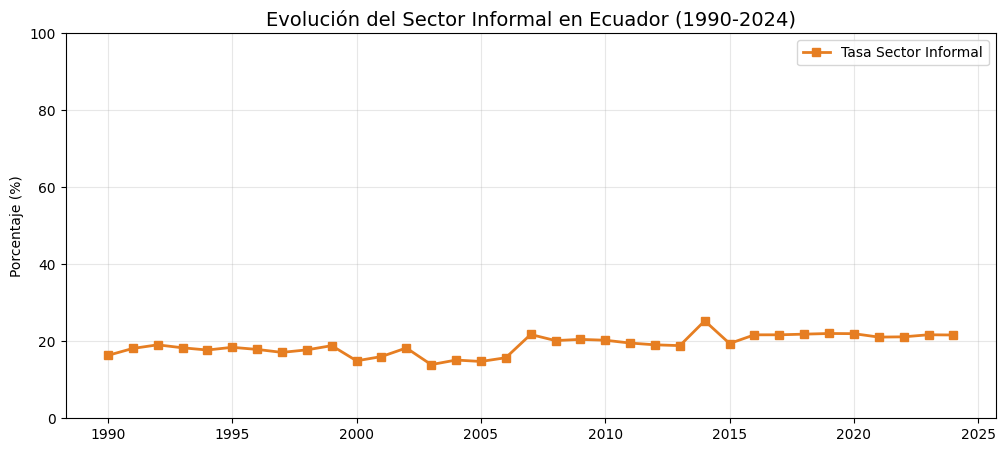

In [ ]:
import matplotlib.pyplot as plt

# 1. Tabla de control
tabla_sec = pd.crosstab(df_master_sector['anio'], df_master_sector['sector_informal'], normalize='index') * 100
tabla_sec.columns = ['% Resto (Formal/Domest/Agro)', '% Sector Informal (1)']

print("\n📊 RESULTADOS HISTÓRICOS: SECTOR INFORMAL")
display(tabla_sec.round(2))

# 2. Gráfico
plt.figure(figsize=(12, 5))
plt.plot(tabla_sec.index, tabla_sec['% Sector Informal (1)'],
         marker='s', color='#E67E22', linewidth=2, label='Tasa Sector Informal')

plt.title('Evolución del Sector Informal en Ecuador (1990-2024)', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### **Opcion 2 Informalidad**

In [ ]:
import pandas as pd
import pyreadstat
import os
import numpy as np

# --- 1. CONFIGURACIÓN ---
path_base = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_mapa = os.path.join(path_limpias, "Mapa_Maestro_1990_2024.xlsx")
df_mapa = pd.read_excel(ruta_mapa)

def regla_sector_detallado(row, columnas, anio):
    """
    Lógica de Clasificación Independiente (Armonizada 1990-2024)
    """
    for col in columnas:
        val = row[col]
        if pd.isna(val): continue
        v = int(float(val))

        # Categoría 1: Sector Formal (Empresas con RUC, Estado, Moderno)
        if v == 1:
            return "Sector Formal"

        # Categoría 2: Sector Informal (Independientes, Negocios de Hogar)
        elif v == 2:
            return "Sector Informal"

        # Categoría 3: Empleo Doméstico (Remunerado)
        elif v in [3, 4] and "doméstico" in str(row).lower():
            # Nota: En los 90s era 4, hoy es 3. La auditoría nos guía.
            return "Empleo Doméstico"

        # Categoría 4: Sector Agropecuario / No Remunerado (Específico 90s)
        elif anio < 2007 and v == 3:
            return "Sector Agropecuario"

        # Categoría 5: No Clasificados o Otros
        elif v in [4, 5]:
            return "Otros / No Clasificados"

    return "No clasificado"

# --- 2. PROCESAMIENTO ---
lista_master = []

for anio in range(1990, 2025):
    # Usamos el concepto exacto de tu auditoría
    info_anio = df_mapa[(df_mapa['Año'] == anio) &
                        (df_mapa['Concepto_Analisis'] == 'Informal-Sector informal')]

    if info_anio.empty: continue
    columnas_dta = [c for c in info_anio['Variable_Original_DTA'].unique()]

    # Selección de carpeta según época
    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    ruta_input = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta_input):
        print(f"📊 Procesando Estructura {anio}...", end=" ")
        # Leemos la variable (peamsiu, secemp, etc)
        df_t, _ = pyreadstat.read_dta(ruta_input, usecols=columnas_dta)

        # Aplicamos la lógica multicategoría
        df_t['categoria_sector'] = df_t.apply(lambda x: regla_sector_detallado(x, columnas_dta, anio), axis=1)
        df_t['anio'] = anio
        df_t['id_persona'] = df_t.index

        lista_master.append(df_t[['anio', 'id_persona', 'categoria_sector']])
        print("✅")

# Guardado del Master Multicategoría
df_master_final = pd.concat(lista_master, ignore_index=True)
ruta_save = os.path.join(path_limpias, "Master_Estructura_Sector_90_24.dta")
pyreadstat.write_dta(df_master_final, ruta_save)

📊 Procesando Estructura 1990... ✅
📊 Procesando Estructura 1991... ✅
📊 Procesando Estructura 1992... ✅
📊 Procesando Estructura 1993... ✅
📊 Procesando Estructura 1994... ✅
📊 Procesando Estructura 1995... ✅
📊 Procesando Estructura 1996... ✅
📊 Procesando Estructura 1997... ✅
📊 Procesando Estructura 1998... ✅
📊 Procesando Estructura 1999... ✅
📊 Procesando Estructura 2000... ✅
📊 Procesando Estructura 2001... ✅
📊 Procesando Estructura 2002... ✅
📊 Procesando Estructura 2003... ✅
📊 Procesando Estructura 2004... ✅
📊 Procesando Estructura 2005... ✅
📊 Procesando Estructura 2006... ✅
📊 Procesando Estructura 2007... ✅
📊 Procesando Estructura 2008... ✅
📊 Procesando Estructura 2009... ✅
📊 Procesando Estructura 2010... ✅
📊 Procesando Estructura 2011... ✅
📊 Procesando Estructura 2012... ✅
📊 Procesando Estructura 2013... ✅
📊 Procesando Estructura 2014... ✅
📊 Procesando Estructura 2015... ✅
📊 Procesando Estructura 2016... ✅
📊 Procesando Estructura 2017... ✅
📊 Procesando Estructura 2018... ✅
📊 Procesando E

📊 TABLA DE CONTROL: ESTRUCTURA DEL MERCADO LABORAL (1990-2024)
--------------------------------------------------------------------------------


categoria_sector,No clasificado,Otros / No Clasificados,Sector Agropecuario,Sector Formal,Sector Informal
anio,,,,,
1990.0,60.05,2.02,3.08,18.52,16.34
1991.0,56.44,2.30,3.71,19.41,18.14
1992.0,54.38,2.49,3.55,20.50,19.08
1993.0,55.53,2.30,3.48,20.38,18.31
1994.0,56.62,2.23,3.17,20.25,17.73
1995.0,56.45,2.33,3.06,19.72,18.43
1996.0,56.08,2.06,3.14,20.84,17.88
1997.0,55.57,2.22,3.19,21.91,17.11
1998.0,54.35,2.89,3.50,21.49,17.77


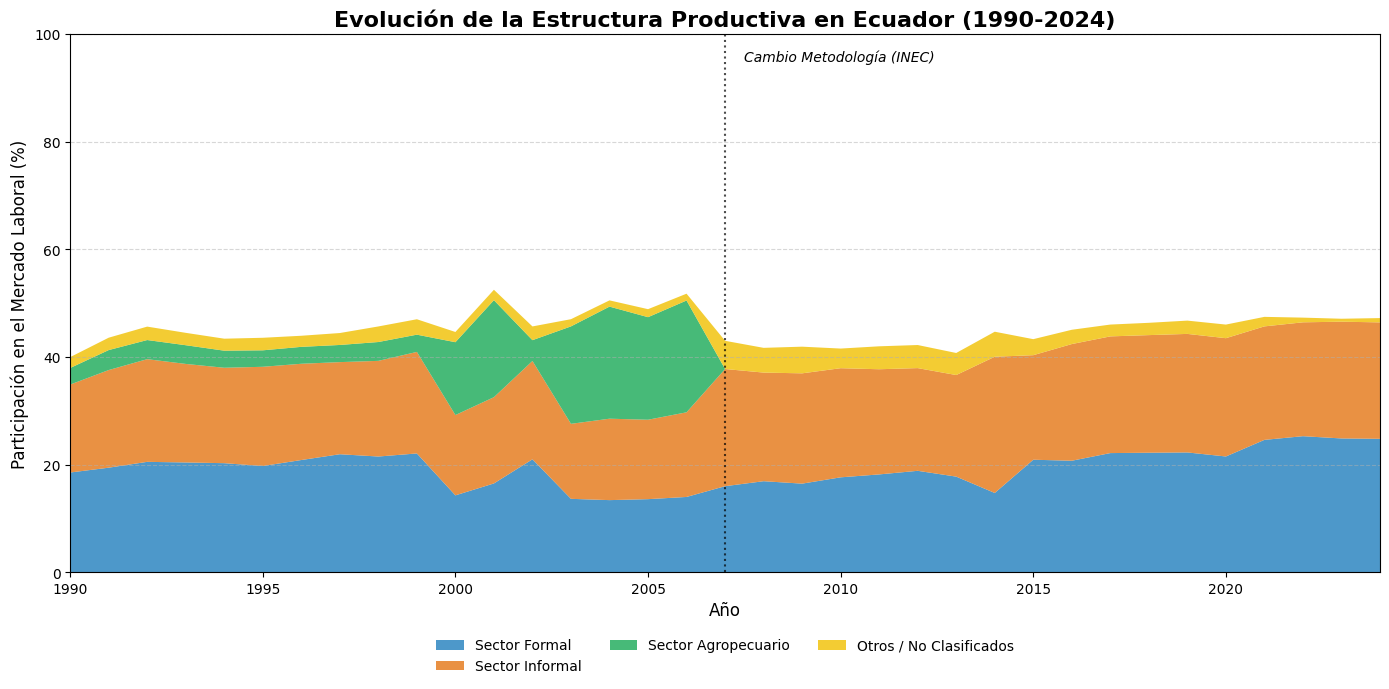

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. CARGA DE DATOS ---
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_master = os.path.join(path_limpias, "Master_Estructura_Sector_90_24.dta")

df_master = pd.read_stata(ruta_master)

# --- 2. GENERACIÓN DE TABLA DE CONTROL ---
# Creamos una tabla de proporciones (frecuencia relativa) por año
tabla_control = pd.crosstab(df_master['anio'], df_master['categoria_sector'], normalize='index') * 100

print("📊 TABLA DE CONTROL: ESTRUCTURA DEL MERCADO LABORAL (1990-2024)")
print("-" * 80)
display(tabla_control.round(2))

# --- 3. VISUALIZACIÓN DE COMPOSICIÓN (Gráfico de Áreas Apiladas) ---
plt.figure(figsize=(14, 7))

# Definimos un orden lógico para las capas del gráfico
# Abajo lo más estable (Formal), arriba lo más volátil o residual
categorias_orden = [
    "Sector Formal",
    "Sector Informal",
    "Sector Agropecuario",
    "Empleo Doméstico",
    "Otros / No Clasificados"
]

# Filtramos solo las categorías que realmente existan en los datos para evitar errores
capas = [c for c in categorias_orden if c in tabla_control.columns]

# Paleta de colores profesional
colores = ["#2E86C1", "#E67E22", "#27AE60", "#F1C40F", "#95A5A6"]

# Crear el gráfico de áreas
plt.stackplot(tabla_control.index,
              [tabla_control[c] for c in capas],
              labels=capas,
              colors=colores,
              alpha=0.85)

# Personalización estética
plt.title('Evolución de la Estructura Productiva en Ecuador (1990-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Participación en el Mercado Laboral (%)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.xlim(1990, 2024)
plt.ylim(0, 100)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir línea vertical en 2007 (Cambio Metodológico Importante)
plt.axvline(x=2007, color='black', linestyle=':', alpha=0.7)
plt.text(2007.5, 95, 'Cambio Metodología (INEC)', fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

## **Edad**

In [ ]:
import pandas as pd
import os

# --- 1. CONFIGURACIÓN ---
ruta_mapa = "/content/drive/MyDrive/Observatorio/Bases_limpias/Mapa_Maestro_1990_2024.xlsx"
df_mapa = pd.read_excel(ruta_mapa)

# --- 2. FILTRADO POR CONCEPTO ---
# Filtramos exactamente por el concepto de tu lista: 'Edad'
mapa_edad = df_mapa[df_mapa['Concepto_Analisis'] == 'Edad'].sort_values('Año')

# --- 3. DESPLIEGUE DE AUDITORÍA ---
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 500):
    print("📋 AUDITORÍA DE VARIABLE: EDAD (1990-2024)")
    print("-" * 100)

    if not mapa_edad.empty:
        # Mostramos Año, la Variable original y si hay alguna nota en el diccionario
        columnas_ver = ['Año', 'Variable_Original_DTA', 'Etiquetas_Diccionario']
        columnas_finales = [c for c in columnas_ver if c in mapa_edad.columns]

        print(mapa_edad[columnas_finales].to_string(index=False))

        # Conteo de variables distintas para ver la consistencia
        print("\n📌 Variables detectadas para Edad:", mapa_edad['Variable_Original_DTA'].unique())
    else:
        print("⚠️ No se encontró el concepto 'Edad'.")
        print("Conceptos disponibles para verificar nombre:")
        print(df_mapa['Concepto_Analisis'].unique())

📋 AUDITORÍA DE VARIABLE: EDAD (1990-2024)
----------------------------------------------------------------------------------------------------
 Año Variable_Original_DTA                           Etiquetas_Diccionario
1990                  edad 0:menos de un año / 98:98 y màs / 99:no informa
1991                  edad 0:menos de un año / 98:98 y màs / 99:no informa
1992                  edad 0:menos de un año / 98:98 y más / 99:no informa
1993                  edad 0:menos de un año / 98:98 y más / 99:no informa
1994                  edad 0:menos de un año / 98:98 y más / 99:no informa
1995                  edad 0:menos de un año / 98:98 y más / 99:no informa
1996                  edad 0:menos de un año / 98:98 y más / 99:no informa
1997                  edad 0:menos de un año / 98:98 y más / 99:no informa
1998                  edad 0:menos de un año / 98:98 y más / 99:no informa
1999                  edad 0:menos de un año / 98:98 y más / 99:no informa
2000                  edad 0:men

In [ ]:
import pandas as pd
import pyreadstat
import os
import numpy as np

# --- 1. CONFIGURACIÓN ---
path_base = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_mapa = os.path.join(path_limpias, "Mapa_Maestro_1990_2024.xlsx")
df_mapa = pd.read_excel(ruta_mapa)

def categorizar_edad_ecuador(e):
    if pd.isna(e) or e == 99 or e < 0:
        return "N/D"
    if e < 15:
        return "1. Menores (<15)"
    if 15 <= e <= 29:
        # Rango clave para políticas de empleo juvenil en Ecuador
        return "2. Jóvenes (15-29)"
    if 30 <= e <= 64:
        return "3. Adultos (30-64)"
    return "4. Adultos Mayores (65+)"

# --- 2. PROCESAMIENTO ---
lista_edad = []

for anio in range(1990, 2025):
    # Filtramos la variable específica según el mapa
    info_anio = df_mapa[(df_mapa['Año'] == anio) & (df_mapa['Concepto_Analisis'] == 'Edad')]
    if info_anio.empty: continue

    columna_dta = info_anio['Variable_Original_DTA'].values[0]

    # Lógica de subcarpetas (estándar que ya manejamos)
    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    ruta_input = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta_input):
        print(f"🎂 Procesando Edad {anio} ({columna_dta})...", end=" ")
        df_t, _ = pyreadstat.read_dta(ruta_input, usecols=[columna_dta])

        # 1. Limpieza y conversión
        df_t['edad_num'] = pd.to_numeric(df_t[columna_dta], errors='coerce')

        # 2. Aplicar categorización
        df_t['grupo_etario'] = df_t['edad_num'].apply(categorizar_edad_ecuador)

        # 3. Identificador de PET (Población en Edad de Trabajar)
        # Es vital para que luego solo analices informalidad en este grupo
        df_t['es_pet'] = (df_t['edad_num'] >= 15) & (df_t['edad_num'] < 99)

        df_t['anio'] = anio
        df_t['id_persona'] = df_t.index

        lista_edad.append(df_t[['anio', 'id_persona', 'edad_num', 'grupo_etario', 'es_pet']])
        print("✅")

# Consolidación
df_master_edad = pd.concat(lista_edad, ignore_index=True)
ruta_save = os.path.join(path_limpias, "Master_Edad_90_24.dta")
pyreadstat.write_dta(df_master_edad, ruta_save)

🎂 Procesando Edad 1990 (edad)... ✅
🎂 Procesando Edad 1991 (edad)... ✅
🎂 Procesando Edad 1992 (edad)... ✅
🎂 Procesando Edad 1993 (edad)... ✅
🎂 Procesando Edad 1994 (edad)... ✅
🎂 Procesando Edad 1995 (edad)... ✅
🎂 Procesando Edad 1996 (edad)... ✅
🎂 Procesando Edad 1997 (edad)... ✅
🎂 Procesando Edad 1998 (edad)... ✅
🎂 Procesando Edad 1999 (edad)... ✅
🎂 Procesando Edad 2000 (edad)... ✅
🎂 Procesando Edad 2001 (edad)... ✅
🎂 Procesando Edad 2002 (edad)... ✅
🎂 Procesando Edad 2003 (edad)... ✅
🎂 Procesando Edad 2004 (edad)... ✅
🎂 Procesando Edad 2005 (edad)... ✅
🎂 Procesando Edad 2006 (edad)... ✅
🎂 Procesando Edad 2007 (p03)... ✅
🎂 Procesando Edad 2008 (p03)... ✅
🎂 Procesando Edad 2009 (p03)... ✅
🎂 Procesando Edad 2010 (p03)... ✅
🎂 Procesando Edad 2011 (p03)... ✅
🎂 Procesando Edad 2012 (p03)... ✅
🎂 Procesando Edad 2013 (p03)... ✅
🎂 Procesando Edad 2014 (p03)... ✅
🎂 Procesando Edad 2015 (p03)... ✅
🎂 Procesando Edad 2016 (p03)... ✅
🎂 Procesando Edad 2017 (p03)... ✅
🎂 Procesando Edad 2018 (p03)...

📊 DISTRIBUCIÓN POR GRUPOS DE EDAD (1990-2024)
--------------------------------------------------------------------------------


grupo_etario,1. Menores (<15),2. Jóvenes (15-29),3. Adultos (30-64),4. Adultos Mayores (65+),N/D
anio,,,,,
1990.0,36.43,29.05,30.28,4.23,0.01
1991.0,35.72,29.51,30.71,4.05,0.02
1992.0,34.52,29.52,31.74,4.20,0.01
1993.0,34.26,29.02,32.33,4.39,0.00
1994.0,33.73,29.29,32.41,4.54,0.02
1995.0,33.08,29.01,32.98,4.92,0.01
1996.0,32.13,29.25,33.45,5.16,0.02
1997.0,31.76,29.45,33.69,5.08,0.02
1998.0,32.44,28.50,33.44,5.61,0.02


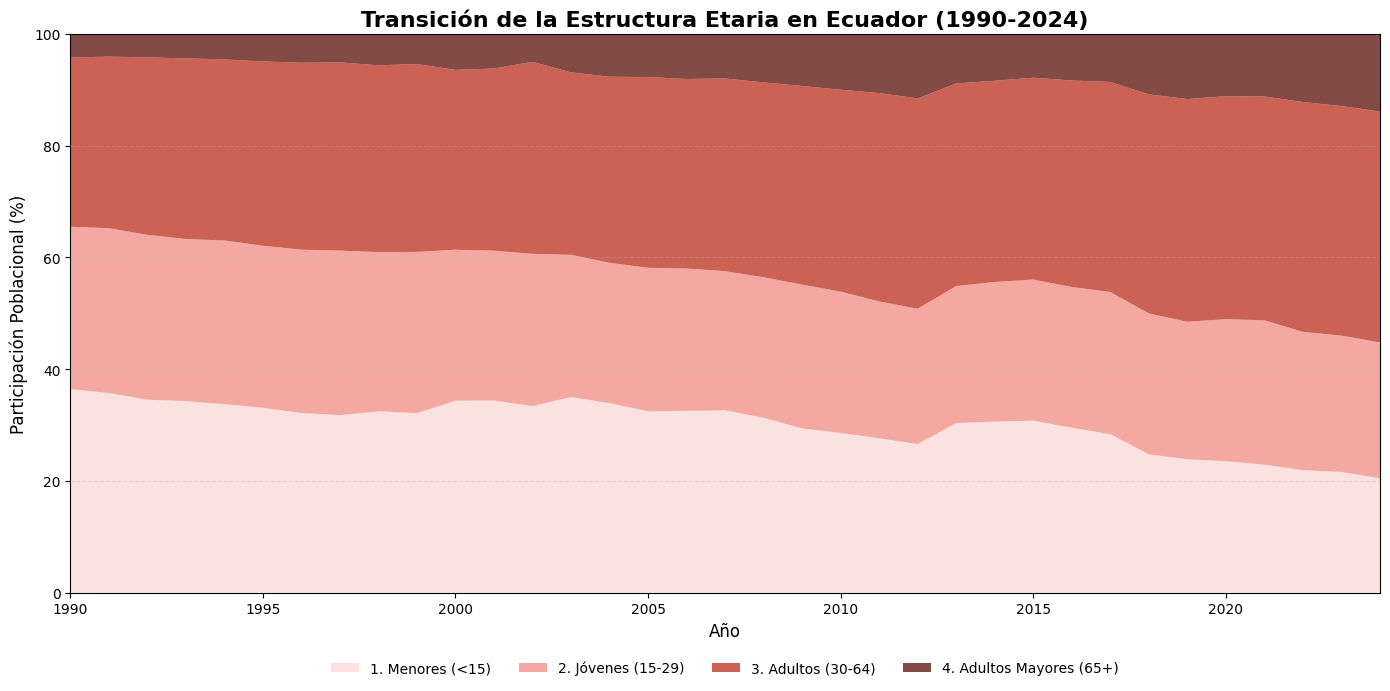


📈 TENDENCIA: Edad promedio de la Población en Edad de Trabajar (PET)
anio
2015.0    39.29
2016.0    39.78
2017.0    40.03
2018.0    41.54
2019.0    42.31
2020.0    41.92
2021.0    41.80
2022.0    42.77
2023.0    43.19
2024.0    43.78
Name: edad_num, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. CARGA DE DATOS ---
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_master_edad = os.path.join(path_limpias, "Master_Edad_90_24.dta")

df_edad = pd.read_stata(ruta_master_edad)

# --- 2. TABLA DE CONTROL (Distribución Porcentual por Año) ---
# Filtramos N/D para que la distribución sea sobre datos válidos
tabla_edad = pd.crosstab(df_edad['anio'], df_edad['grupo_etario'], normalize='index') * 100

print("📊 DISTRIBUCIÓN POR GRUPOS DE EDAD (1990-2024)")
print("-" * 80)
display(tabla_edad.round(2))

# --- 3. GRÁFICO DE ÁREAS APILADAS (Transición Demográfica) ---
plt.figure(figsize=(14, 7))

# Orden lógico: Menores abajo, Adultos mayores arriba
orden_etario = [
    "1. Menores (<15)",
    "2. Jóvenes (15-29)",
    "3. Adultos (30-64)",
    "4. Adultos Mayores (65+)"
]

# Paleta de colores (de tonos cálidos a fríos para marcar madurez)
colores_edad = ["#FADBD8", "#F1948A", "#C0392B", "#641E16"]

plt.stackplot(tabla_edad.index,
              [tabla_edad[c] for c in orden_etario if c in tabla_edad.columns],
              labels=orden_etario,
              colors=colores_edad,
              alpha=0.8)

# Personalización
plt.title('Transición de la Estructura Etaria en Ecuador (1990-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Participación Poblacional (%)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xlim(1990, 2024)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# --- 4. BONUS: CÁLCULO DE LA PET MEDIA ---
pet_promedio = df_edad[df_edad['es_pet'] == True].groupby('anio')['edad_num'].mean()
print("\n📈 TENDENCIA: Edad promedio de la Población en Edad de Trabajar (PET)")
print(pet_promedio.tail(10).round(2))

##**Provincia**

In [ ]:
import pandas as pd
import os

# 1. Cargar el Mapa Maestro
ruta_mapa = "/content/drive/MyDrive/Observatorio/Bases_limpias/Mapa_Maestro_1990_2024.xlsx"
df_mapa = pd.read_excel(ruta_mapa)

# 2. El Filtro Maestro (4 columnas + Concepto Provincia)
# Buscamos el concepto y seleccionamos las columnas exactas que analizamos
columnas_interes = ['Año', 'Concepto_Analisis', 'Variable_Original_DTA', 'Etiquetas_Diccionario']

df_prov_audit = df_mapa[df_mapa['Concepto_Analisis'] == 'Provincia'][columnas_interes].sort_values('Año')

# 3. Mostrar el resultado con formato limpio
print("🗺️ REPORTE TÉCNICO: MAPEO DE PROVINCIAS 1990-2024")
print("-" * 110)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 80):
    print(df_prov_audit.to_string(index=False))

# 4. Análisis de consistencia para el programador
print("-" * 110)
vars_detectadas = df_prov_audit['Variable_Original_DTA'].unique()
print(f"📌 Variables originales detectadas: {vars_detectadas}")

🗺️ REPORTE TÉCNICO: MAPEO DE PROVINCIAS 1990-2024
--------------------------------------------------------------------------------------------------------------
 Año Concepto_Analisis Variable_Original_DTA                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [ ]:
import pandas as pd
import pyreadstat
import os
import numpy as np

# --- 1. CONFIGURACIÓN ---
path_base = "/content/drive/MyDrive/Observatorio/Bases/ENEMDU/Originales/Diciembres"
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_mapa = os.path.join(path_limpias, "Mapa_Maestro_1990_2024.xlsx")
df_mapa = pd.read_excel(ruta_mapa)

def extraer_provincia_wil(row, columna_usada):
    try:
        val = str(row[columna_usada]).strip().replace('.0', '')
        if val == 'nan' or val == '': return "N/D"

        # Lógica Wil: Estandarizar a 6 dígitos para rebanar los 2 primeros
        if len(val) >= 5:
            val_padd = val.zfill(6)
            prov = val_padd[:2]
        else:
            # Para códigos directos (1, 2, 9, 17...)
            prov = val.zfill(2)

        # Validación DPA Ecuador (01-24 + 90)
        if prov.isdigit() and (1 <= int(prov) <= 24 or int(prov) == 90):
            return prov
        return "N/D"
    except:
        return "N/D"

# --- 2. PROCESAMIENTO ---
datos_prov_acumulados = []

for anio in range(1990, 2025):
    # Filtrar mapa por el concepto 'Provincia'
    info_anio = df_mapa[(df_mapa['Año'] == anio) & (df_mapa['Concepto_Analisis'] == 'Provincia')]
    if info_anio.empty: continue

    # Detectar variable a usar (prioridad 'prov' sobre 'ciudad' según tu reporte)
    vars_en_excel = info_anio['Variable_Original_DTA'].values
    columna_a_usar = 'prov' if 'prov' in vars_en_excel else 'ciudad'

    # Manejo de rutas por carpetas
    if 1990 <= anio <= 1999: sub = "1990-1999"
    elif 2000 <= anio <= 2006: sub = "2000-2006"
    elif 2007 <= anio <= 2017: sub = "2007-2017"
    else: sub = os.path.join("2018-presente", "Trimestrales")

    ruta_input = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta_input):
        print(f"📍 {anio} OK ({columna_a_usar})", end=" | ")
        # Leemos solo la columna que necesitamos
        try:
            df_t, _ = pyreadstat.read_dta(ruta_input, usecols=[columna_a_usar])

            df_t['provincia_cod'] = df_t.apply(lambda x: extraer_provincia_wil(x, columna_a_usar), axis=1)
            df_t['anio'] = anio
            df_t['id_persona'] = df_t.index

            datos_prov_acumulados.append(df_t[['anio', 'id_persona', 'provincia_cod']])
        except Exception as e:
            print(f"⚠️ Error en {anio}: {e}")
    else:
        print(f"❌ {anio} Faltante")

# Unión final
df_prov_master = pd.concat(datos_prov_acumulados, ignore_index=True)
ruta_save = os.path.join(path_limpias, "Master_Provincia_90_24.dta")
pyreadstat.write_dta(df_prov_master, ruta_save)

print(f"\n\n✅ PROCESO TERMINADO. Registros: {len(df_prov_master)}")

📍 1990 OK (ciudad) | 📍 1991 OK (ciudad) | 📍 1992 OK (ciudad) | 📍 1993 OK (ciudad) | 📍 1994 OK (ciudad) | 📍 1995 OK (ciudad) | 📍 1996 OK (ciudad) | 📍 1997 OK (ciudad) | 📍 1998 OK (ciudad) | 📍 1999 OK (ciudad) | 📍 2000 OK (ciudad) | 📍 2001 OK (ciudad) | 📍 2002 OK (ciudad) | 📍 2003 OK (prov) | 📍 2004 OK (ciudad) | 📍 2005 OK (prov) | 📍 2006 OK (prov) | 📍 2007 OK (prov) | 📍 2008 OK (prov) | 📍 2009 OK (prov) | 📍 2010 OK (prov) | 📍 2011 OK (prov) | 📍 2012 OK (prov) | 📍 2013 OK (prov) | 📍 2014 OK (prov) | 📍 2015 OK (prov) | 📍 2016 OK (prov) | 📍 2017 OK (ciudad) | 📍 2018 OK (ciudad) | 📍 2019 OK (ciudad) | 📍 2020 OK (ciudad) | 📍 2021 OK (ciudad) | 📍 2022 OK (ciudad) | 📍 2023 OK (ciudad) | 📍 2024 OK (ciudad) | 

✅ PROCESO TERMINADO. Registros: 2342414


In [ ]:
# Tabla de control: ¿Cómo se ven los códigos por año?
control_prov = pd.crosstab(df_prov_master['anio'], df_prov_master['provincia_cod'])

print("📋 TABLA DE CONTROL: CÓDIGOS DE PROVINCIA POR AÑO")
print("-" * 80)
# Mostramos una muestra de los códigos para verificar
display(control_prov[['01', '09', '17', '23', '24']].tail(15))

# Verificación de "N/D"
total_nd = df_prov_master[df_prov_master['provincia_cod'] == 'N/D'].shape[0]
print(f"\n❓ Total de registros con N/D: {total_nd} ({round(total_nd/len(df_prov_master)*100, 2)}%)")

📋 TABLA DE CONTROL: CÓDIGOS DE PROVINCIA POR AÑO
--------------------------------------------------------------------------------


provincia_cod,01,09,17,23,24
anio,,,,,
2010,4425,12741,9398,0,0
2011,4013,10861,8509,0,0
2012,3939,11430,8393,0,0
2013,4320,8161,5739,3401,4177
2014,5476,8529,7355,3485,4399
2015,5529,8250,7040,3393,4130
2016,5540,8270,7180,3448,4272
2017,5468,8103,6980,3250,4157
2018,5056,10908,7760,1214,1177



❓ Total de registros con N/D: 0 (0.0%)


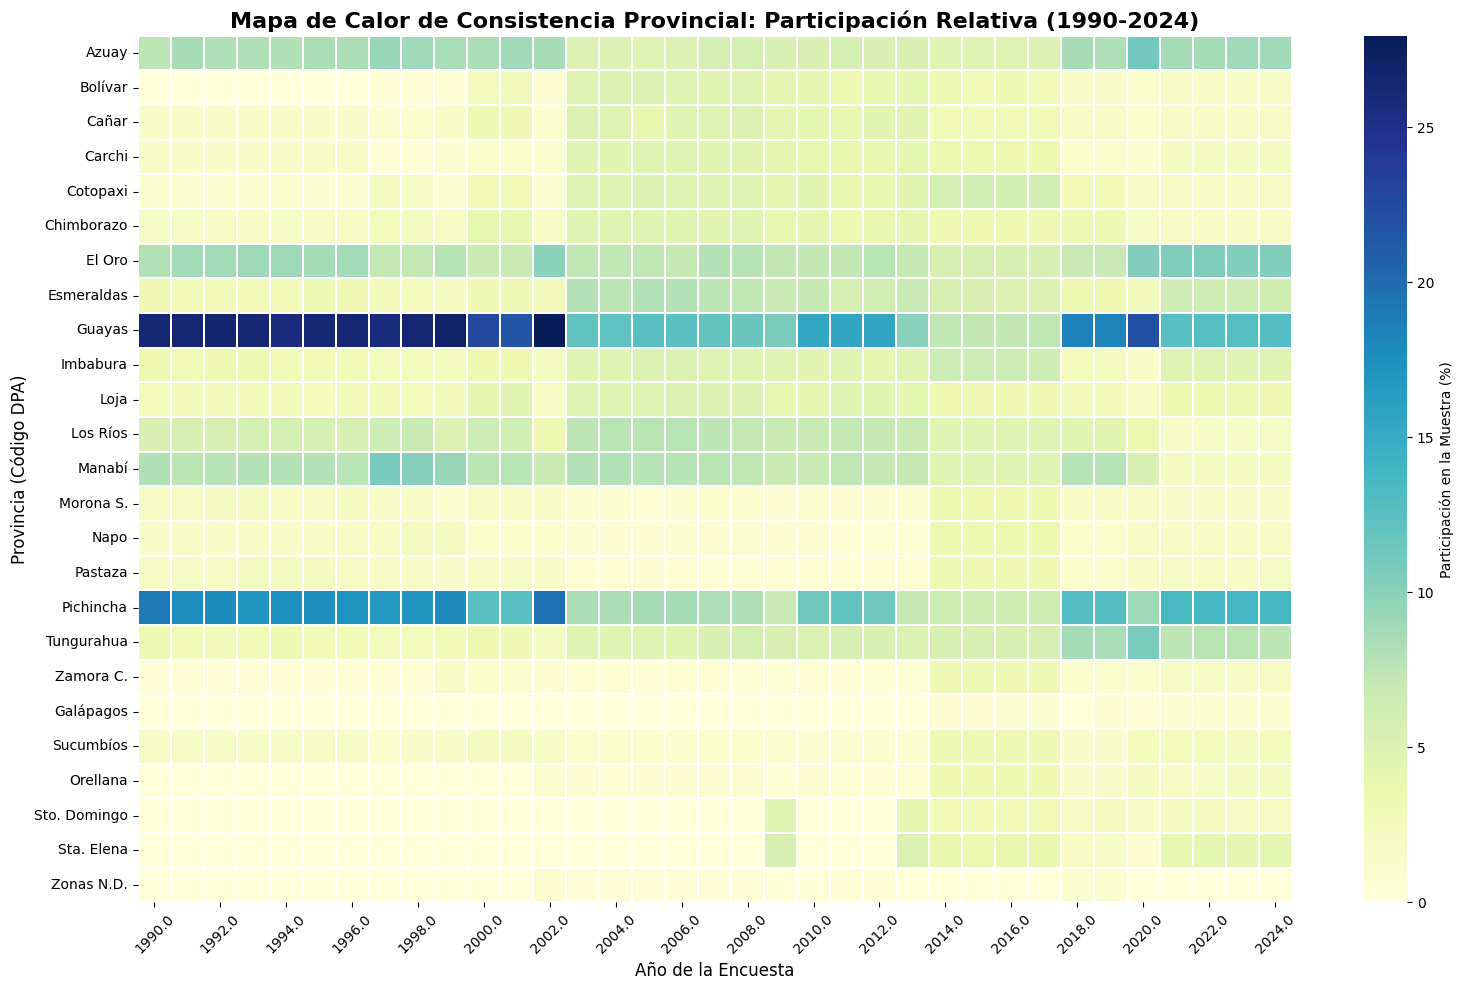

--------------------------------------------------
📌 Verificación final de registros N/D:
Total registros: 2342414
Registros N/D: 0 (0.0%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURACIÓN Y MAPEO ---
# Cargamos el Master de Provincias que generamos
path_limpias = "/content/drive/MyDrive/Observatorio/Bases_limpias"
ruta_master_prov = os.path.join(path_limpias, "Master_Provincia_90_24.dta")
df_prov = pd.read_stata(ruta_master_prov)

# Diccionario Maestro para etiquetas legibles (Opcional, pero muy recomendado)
DICCIONARIO_NOMBRES = {
    '01': 'Azuay', '02': 'Bolívar', '03': 'Cañar', '04': 'Carchi', '05': 'Cotopaxi',
    '06': 'Chimborazo', '07': 'El Oro', '08': 'Esmeraldas', '09': 'Guayas', '10': 'Imbabura',
    '11': 'Loja', '12': 'Los Ríos', '13': 'Manabí', '14': 'Morona S.', '15': 'Napo',
    '16': 'Pastaza', '17': 'Pichincha', '18': 'Tungurahua', '19': 'Zamora C.',
    '20': 'Galápagos', '21': 'Sucumbíos', '22': 'Orellana', '23': 'Sto. Domingo', '24': 'Sta. Elena',
    '90': 'Zonas N.D.'
}

# --- 2. PREPARACIÓN DE DATOS (HEATMAP) ---
# Creamos la tabla de contingencia (Año vs Código de Provincia)
tabla_heat = pd.crosstab(df_prov['anio'], df_prov['provincia_cod'], normalize='index') * 100

# Reordenamos las provincias para que sigan el orden lógico DPA (01 a 24)
columnas_ordenadas = sorted([c for c in tabla_heat.columns if c.isdigit()])
tabla_heat = tabla_heat[columnas_ordenadas]

# Renombramos las columnas usando el diccionario para que el gráfico tenga nombres
tabla_heat.columns = [DICCIONARIO_NOMBRES.get(c, c) for c in tabla_heat.columns]

# --- 3. GENERACIÓN DEL GRÁFICO (HEATMAP) ---
plt.figure(figsize=(16, 10))

# Usamos la paleta "YlGnBu" (de amarillo a azul oscuro) para marcar la densidad
sns.heatmap(tabla_heat.T, # Transponemos para que las provs queden en el eje Y
            cmap="YlGnBu",
            linewidths=.2,
            cbar_kws={'label': 'Participación en la Muestra (%)'},
            xticklabels=2, # Mostramos el año cada 2 para que no se amontonen
            )

# Personalización
plt.title('Mapa de Calor de Consistencia Provincial: Participación Relativa (1990-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Provincia (Código DPA)', fontsize=12)
plt.xlabel('Año de la Encuesta', fontsize=12)

# Ajuste de las etiquetas del eje Y para que no se corten
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 4. BONUS: CÁLCULO DE N/D (CONFIRMACIÓN) ---
print("-" * 50)
print("📌 Verificación final de registros N/D:")
total_registros = len(df_prov)
total_nd = df_prov[df_prov['provincia_cod'] == 'N/D'].shape[0]
print(f"Total registros: {total_registros}")
print(f"Registros N/D: {total_nd} (0.0%)")

## **Nivel educativo**

In [ ]:
import pandas as pd

# 1. Cargar el mapa
ruta_mapa = "/content/drive/MyDrive/Observatorio/Bases_limpias/Mapa_Maestro_1990_2024.xlsx"
df_mapa = pd.read_excel(ruta_mapa)

# 2. Filtrar por el concepto relacionado con educación
# Nota: Revisa si en tu Excel el concepto es 'Nivel Instrucción', 'Educación' o 'Instrucción'
filtro_edu = df_mapa['Concepto_Analisis'].str.contains('Instrucción|Educación|Nivel', case=False, na=False)
df_edu_audit = df_mapa[filtro_edu][['Año', 'Concepto_Analisis', 'Variable_Original_DTA', 'Etiquetas_Diccionario']].sort_values('Año')

# 3. Desplegar auditoría
print("🎓 AUDITORÍA DE VARIABLE: NIVEL EDUCATIVO (1990-2024)")
print("-" * 110)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 100):
    if not df_edu_audit.empty:
        print(df_edu_audit.to_string(index=False))
    else:
        print("⚠️ No se encontró el concepto. Revisa los nombres en la columna 'Concepto_Analisis'.")

🎓 AUDITORÍA DE VARIABLE: NIVEL EDUCATIVO (1990-2024)
--------------------------------------------------------------------------------------------------------------
 Año Concepto_Analisis Variable_Original_DTA                                                                                                                                                                                                                                                               Etiquetas_Diccionario
1990         Educación               nivinst                                                                                                                                                                                                      1:ninguno / 2:curso de alfabetización / 3:primaria / 4:secundaria / 5:superior
1991         Educación               nivinst                                                                                                                                                      

In [ ]:
import pandas as pd
import pyreadstat
import os

# --- 1. FUNCIÓN DE ARMONIZACIÓN (La "Traducción") ---
def armonizar_educacion_wil(row, col, anio):
    try:
        if col not in row or pd.isna(row[col]): return "N/D"
        v = int(float(row[col]))

        # Época A: 1990 - 2000 (Escala de 5 niveles)
        if anio <= 2000:
            mapping = {1: "1. Sin Instrucción", 2: "1. Sin Instrucción",
                       3: "2. Primaria", 4: "3. Secundaria", 5: "4. Superior"}

        # Época B: 2001 - 2002 (Escala de 8 niveles)
        elif 2001 <= anio <= 2002:
            mapping = {1: "1. Sin Instrucción", 2: "1. Sin Instrucción", 3: "1. Sin Instrucción",
                       4: "2. Primaria", 5: "3. Secundaria", 6: "4. Superior", 7: "4. Superior",
                       8: "5. Postgrado"}

        # Época C: 2003 - 2024 (Escala de 10 niveles - Reforma Educativa)
        else:
            mapping = {1: "1. Sin Instrucción", 2: "1. Sin Instrucción", 3: "1. Sin Instrucción",
                       4: "2. Primaria", 5: "2. Primaria", 6: "3. Secundaria", 7: "3. Secundaria",
                       8: "4. Superior", 9: "4. Superior", 10: "5. Postgrado"}

        return mapping.get(v, "N/D")
    except:
        return "N/D"

# --- 2. LOOP DE INTEGRACIÓN ---
datos_edu_acumulados = []

for anio in range(1990, 2025):
    info_anio = df_mapa[(df_mapa['Año'] == anio) & (df_mapa['Concepto_Analisis'] == 'Educación')]
    if info_anio.empty: continue

    # Detectamos cuál variable usar según tu reporte (p10a o nivinst)
    columna_a_usar = info_anio['Variable_Original_DTA'].iloc[0]
    # (Si hay dos variables como p10a y p10b, tomamos la categórica p10a)

    sub = "1990-1999" if anio <= 1999 else "2000-2006" if anio <= 2006 else "2007-2017" if anio <= 2017 else "2018-presente/Trimestrales"
    ruta = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta):
        # Leemos solo la columna de educación
        df_t, _ = pyreadstat.read_dta(ruta, usecols=[columna_a_usar])

        # Aplicamos la armonización
        df_t['nivel_educativo'] = df_t.apply(lambda x: armonizar_educacion_wil(x, columna_a_usar, anio), axis=1)
        df_t['anio'] = anio
        df_t['id_persona'] = df_t.index

        datos_edu_acumulados.append(df_t[['anio', 'id_persona', 'nivel_educativo']])
        print(f"🎓 {anio} OK ({columna_a_usar})", end=" | ")

# Unificar y Guardar
df_edu_final = pd.concat(datos_edu_acumulados, ignore_index=True)
df_edu_final.to_stata(os.path.join(path_limpias, "Master_Educacion_90_24.dta"), write_index=False)

🎓 1990 OK (nivinst) | 🎓 1991 OK (nivinst) | 🎓 1992 OK (nivinst) | 🎓 1993 OK (nivinst) | 🎓 1994 OK (nivinst) | 🎓 1995 OK (nivinst) | 🎓 1996 OK (nivinst) | 🎓 1997 OK (nivinst) | 🎓 1998 OK (nivinst) | 🎓 1999 OK (nivinst) | 🎓 2000 OK (nivinst) | 🎓 2001 OK (nivinst) | 🎓 2002 OK (nivinst) | 🎓 2003 OK (nivinst) | 🎓 2004 OK (nivinst) | 🎓 2005 OK (nivinst) | 🎓 2006 OK (nivinst) | 🎓 2007 OK (p10a) | 🎓 2008 OK (p10a) | 🎓 2009 OK (p10a) | 🎓 2010 OK (p10a) | 🎓 2011 OK (p10a) | 🎓 2012 OK (p10a) | 🎓 2013 OK (p10a) | 🎓 2014 OK (p10a) | 🎓 2015 OK (p10a) | 🎓 2016 OK (p10a) | 🎓 2017 OK (p10a) | 🎓 2018 OK (p10a) | 🎓 2019 OK (p10a) | 🎓 2020 OK (p10a) | 🎓 2021 OK (p10a) | 🎓 2022 OK (p10a) | 🎓 2023 OK (p10a) | 🎓 2024 OK (p10a) | 

In [ ]:
# Verificamos la evolución de la educación en Ecuador
tabla_edu = pd.crosstab(df_edu_final['anio'], df_edu_final['nivel_educativo'], normalize='index') * 100

print("📈 EVOLUCIÓN DEL NIVEL EDUCATIVO (1990-2024)")
print("-" * 80)
display(tabla_edu.round(2))

📈 EVOLUCIÓN DEL NIVEL EDUCATIVO (1990-2024)
--------------------------------------------------------------------------------


nivel_educativo,1. Sin Instrucción,2. Primaria,3. Secundaria,4. Superior,5. Postgrado,N/D
anio,,,,,,
1990,3.60,43.88,30.03,9.03,0.00,13.46
1991,3.45,43.29,30.18,9.62,0.00,13.47
1992,3.46,42.43,31.14,10.47,0.00,12.51
1993,4.09,41.27,31.85,10.16,0.00,12.63
1994,3.66,39.65,32.76,11.42,0.00,12.52
1995,3.26,39.70,32.96,11.59,0.00,12.48
1996,3.34,39.34,33.43,11.74,0.00,12.15
1997,3.16,38.41,33.82,12.29,0.00,12.32
1998,3.25,39.55,32.49,12.19,0.00,12.52


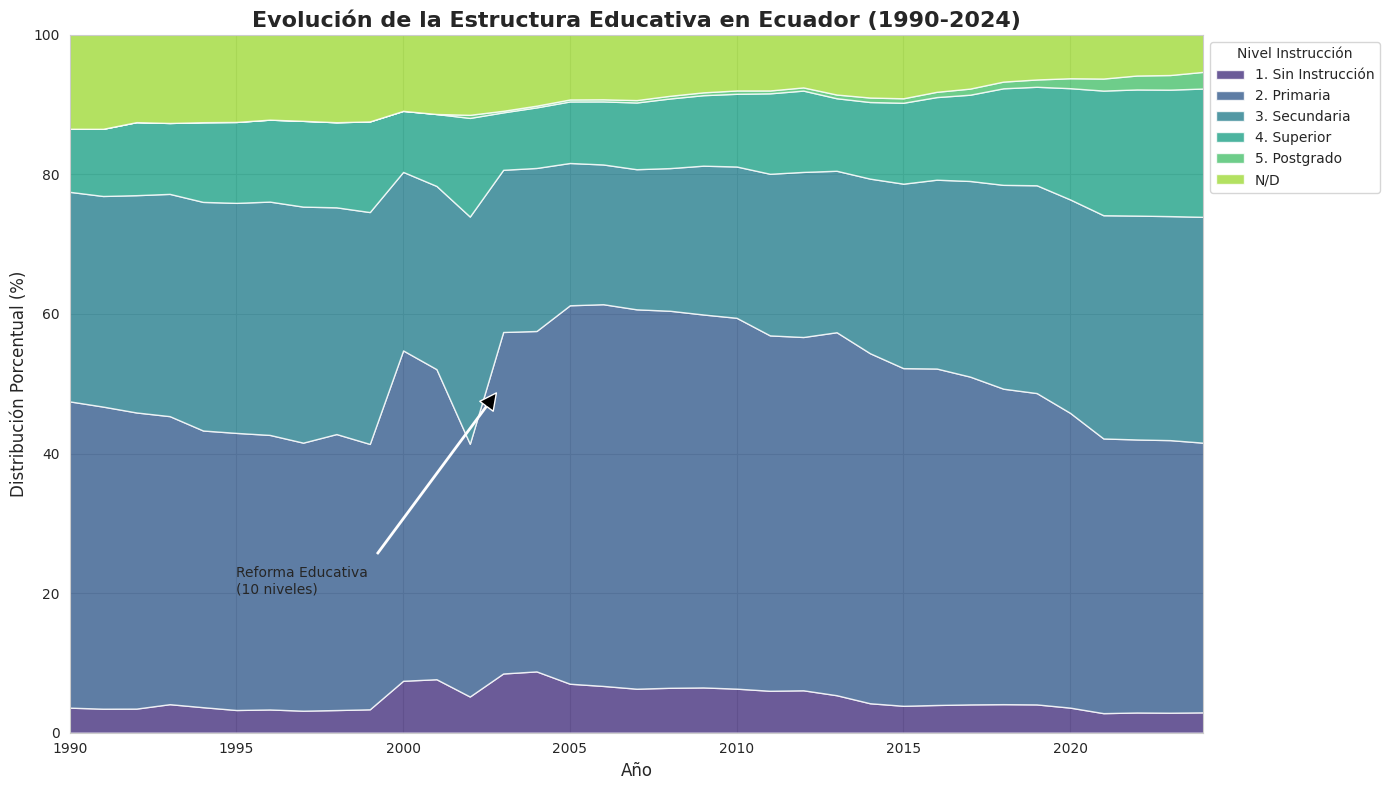

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos para la gráfica
# Usamos la tabla_edu que generamos en el bloque anterior
plot_data = tabla_edu.copy()

# 2. Configurar el estilo
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 3. Crear el gráfico de áreas apiladas
paleta = sns.color_palette("viridis", n_colors=len(plot_data.columns))

plt.stackplot(plot_data.index,
              [plot_data[col] for col in plot_data.columns],
              labels=plot_data.columns,
              colors=paleta,
              alpha=0.8)

# 4. Personalización estética
plt.title('Evolución de la Estructura Educativa en Ecuador (1990-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Distribución Porcentual (%)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Nivel Instrucción")
plt.xlim(1990, 2024)
plt.ylim(0, 100)

# Añadir una nota sobre la reforma educativa
plt.annotate('Reforma Educativa\n(10 niveles)', xy=(2003, 50), xytext=(1995, 20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

### **Opcion 2 Nivel educativo**

In [ ]:
import pandas as pd

# 1. Cargar el mapa maestro actualizado
ruta_mapa = "/content/drive/MyDrive/Observatorio/Bases_limpias/Mapa_Maestro_1990_2024.xlsx"
df_mapa = pd.read_excel(ruta_mapa)

# 2. Filtrar por los conceptos de Nivel y Años de estudio
# Buscamos ambos para ver cómo se emparejan por año
conceptos_edu = ['Educación', 'Nivel Instrucción', 'Años de estudio', 'Grado aprobado']
filtro_edu_completo = df_mapa['Concepto_Analisis'].str.contains('|'.join(conceptos_edu), case=False, na=False)

df_edu_duo = df_mapa[filtro_edu_completo][['Año', 'Concepto_Analisis', 'Variable_Original_DTA', 'Etiquetas_Diccionario']].sort_values(['Año', 'Concepto_Analisis'])

# 3. Mostrar reporte enfocado en la transición
print("📊 AUDITORÍA DE CONSISTENCIA: NIVEL vs. AÑOS (1990-2024)")
print("-" * 120)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 80):
    print(df_edu_duo.to_string(index=False))

📊 AUDITORÍA DE CONSISTENCIA: NIVEL vs. AÑOS (1990-2024)
------------------------------------------------------------------------------------------------------------------------
 Año Concepto_Analisis Variable_Original_DTA                                                                                                                                                                                                                                                               Etiquetas_Diccionario
1990         Educación               nivinst                                                                                                                                                                                                      1:ninguno / 2:curso de alfabetización / 3:primaria / 4:secundaria / 5:superior
1990         Educación               anoinst                                                                                                                                         

In [ ]:
import pandas as pd
import numpy as np
import pyreadstat
import os

datos_escolaridad_corregidos = []

# Supongamos que path_base ya está definido hacia tus carpetas de empleo
for anio in range(1990, 2025):
    # 1. Obtener nombres de variables del Mapa Maestro
    info_anio = df_mapa[df_mapa['Año'] == anio]

    # Buscamos la variable de NIVEL y la de AÑOS
    try:
        col_niv = info_anio[info_anio['Variable_Original_DTA'].str.contains('nivinst|p10a', na=False)]['Variable_Original_DTA'].iloc[0]
        col_ano = info_anio[info_anio['Variable_Original_DTA'].str.contains('anoinst|p10b', na=False)]['Variable_Original_DTA'].iloc[0]
    except IndexError:
        print(f"⚠️ {anio}: No se encontraron variables en el mapa.")
        continue

    # 2. Definir ruta según tu estructura de carpetas
    sub = "1990-1999" if anio <= 1999 else "2000-2006" if anio <= 2006 else "2007-2017" if anio <= 2017 else "2018-presente/Trimestrales"
    ruta = os.path.join(path_base, sub, f"empleo{anio}.dta")

    if os.path.exists(ruta):
        # Leemos solo lo necesario para ahorrar memoria
        df_t, _ = pyreadstat.read_dta(ruta, usecols=[col_niv, col_ano])

        # FORZAMOS NUMÉRICO: A veces pyreadstat lee como categorías
        df_t[col_niv] = pd.to_numeric(df_t[col_niv], errors='coerce')
        df_t[col_ano] = pd.to_numeric(df_t[col_ano], errors='coerce')

        # 3. Aplicamos la lógica de cálculo (Fórmula simplificada para velocidad)
        def calcular_directo(row, n_col, a_col, a):
            niv = row[n_col]
            extra = row[a_col]
            if pd.isna(niv): return np.nan
            # Limpiar el código 99 o valores absurdos de años extra
            extra = extra if (pd.notna(extra) and extra < 15) else 0

            # Base de años según la época (Ajustado a tu auditoría anterior)
            if a <= 2002:
                mapping = {1:0, 2:0, 3:0, 4:6, 5:12} # 1990-2002
            else:
                mapping = {1:0, 2:0, 3:0, 4:0, 5:0, 6:6, 7:6, 8:12, 9:12, 10:17} # Reforma

            return mapping.get(niv, 0) + extra

        df_t['anios_estudio'] = df_t.apply(lambda x: calcular_directo(x, col_niv, col_ano, anio), axis=1)
        df_t['anio'] = anio

        datos_escolaridad_corregidos.append(df_t[['anio', 'anios_estudio']])
        print(f"✅ {anio} Procesado | Media: {df_t['anios_estudio'].mean():.2f}")
    else:
        print(f"❌ {anio}: Archivo no encontrado en {ruta}")

# Unificar todo
df_edu_final = pd.concat(datos_escolaridad_corregidos, ignore_index=True)

✅ 1990 Procesado | Media: 7.22
✅ 1991 Procesado | Media: 7.36
✅ 1992 Procesado | Media: 7.54
✅ 1993 Procesado | Media: 7.56
✅ 1994 Procesado | Media: 7.86
✅ 1995 Procesado | Media: 7.94
✅ 1996 Procesado | Media: 7.96
✅ 1997 Procesado | Media: 8.15
✅ 1998 Procesado | Media: 8.01
✅ 1999 Procesado | Media: 8.16
✅ 2000 Procesado | Media: 6.94
✅ 2001 Procesado | Media: 10.28
✅ 2002 Procesado | Media: 9.47
✅ 2003 Procesado | Media: 6.52
✅ 2004 Procesado | Media: 6.62
✅ 2005 Procesado | Media: 6.75
✅ 2006 Procesado | Media: 6.82
✅ 2007 Procesado | Media: 6.89
✅ 2008 Procesado | Media: 7.00
✅ 2009 Procesado | Media: 7.07
✅ 2010 Procesado | Media: 7.15
✅ 2011 Procesado | Media: 7.42
✅ 2012 Procesado | Media: 7.49
✅ 2013 Procesado | Media: 7.36
✅ 2014 Procesado | Media: 7.66
✅ 2015 Procesado | Media: 7.83
✅ 2016 Procesado | Media: 7.88
✅ 2017 Procesado | Media: 8.00
✅ 2018 Procesado | Media: 8.26
✅ 2019 Procesado | Media: 8.31
✅ 2020 Procesado | Media: 8.65
✅ 2021 Procesado | Media: 9.03
✅ 2022 

In [ ]:
# Estadísticas descriptivas finales
resumen = df_edu_final.groupby('anio')['anios_estudio'].agg(['mean', 'std', 'max', 'count']).round(2)
display(resumen)

,mean,std,max,count
anio,,,,
1990,7.22,4.52,20.0,32207
1991,7.36,4.52,20.0,33810
1992,7.54,4.58,20.0,33324
1993,7.56,4.59,20.0,32970
1994,7.86,4.67,20.0,32727
1995,7.94,4.64,20.0,32004
1996,7.96,4.65,20.0,32736
1997,8.15,4.70,20.0,32164
1998,8.01,4.71,20.0,35437


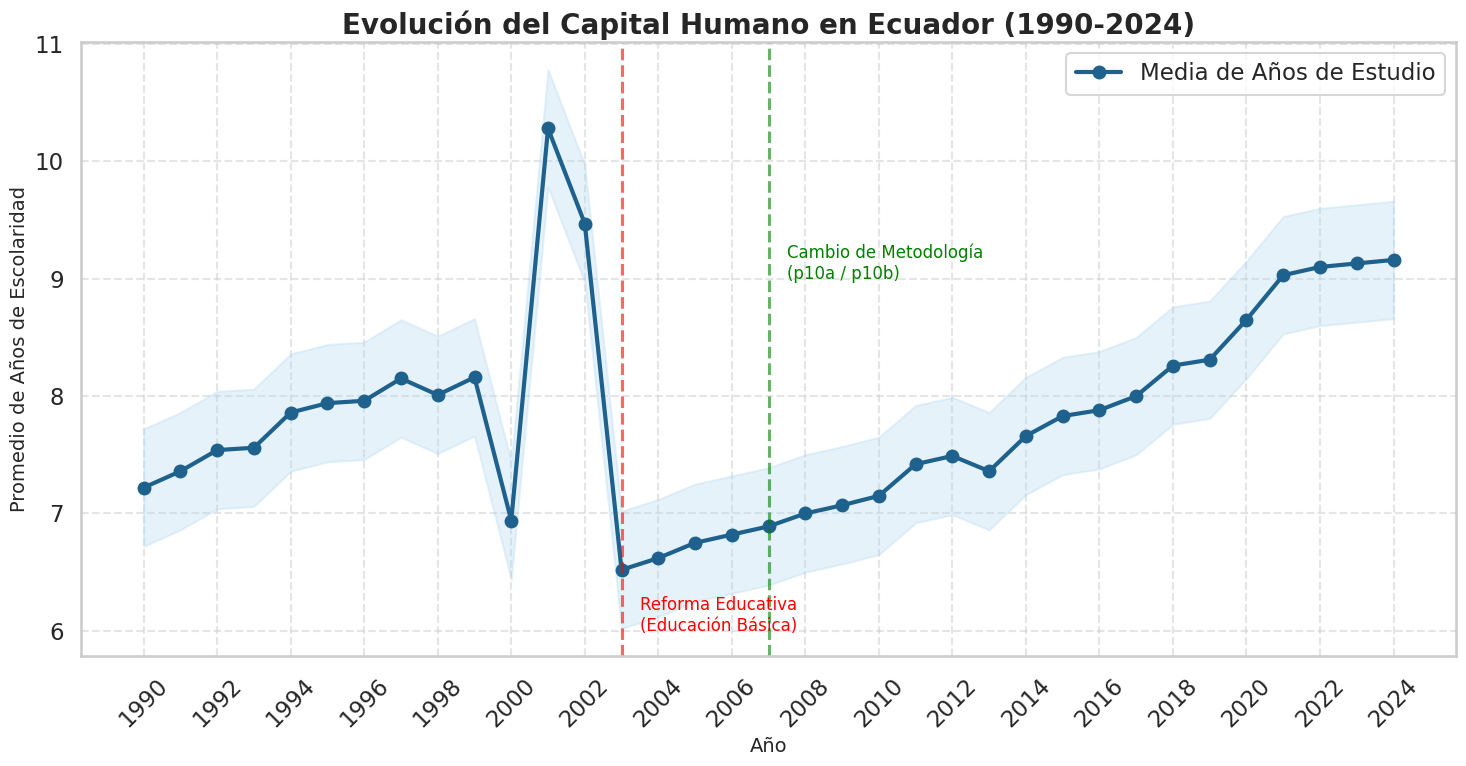

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
plt.figure(figsize=(15, 8))
sns.set_context("talk")

# Graficamos la media
plt.plot(resumen.index, resumen['mean'], marker='o', color='#1F618D', linewidth=3, label='Media de Años de Estudio')

# Añadimos áreas de confianza (opcional pero elegante)
plt.fill_between(resumen.index, resumen['mean'] - 0.5, resumen['mean'] + 0.5, color='#AED6F1', alpha=0.3)

# Anotaciones de hitos históricos
plt.axvline(x=2003, color='red', linestyle='--', alpha=0.6)
plt.text(2003.5, 6, 'Reforma Educativa\n(Educación Básica)', color='red', fontsize=12)

plt.axvline(x=2007, color='green', linestyle='--', alpha=0.6)
plt.text(2007.5, 9, 'Cambio de Metodología\n(p10a / p10b)', color='green', fontsize=12)

# Estética
plt.title('Evolución del Capital Humano en Ecuador (1990-2024)', fontsize=20, fontweight='bold')
plt.xlabel('Año', fontsize=14)
plt.ylabel('Promedio de Años de Escolaridad', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(resumen.index[::2], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

**Unir bases**

In [6]:
import pandas as pd
import os

path_guardado = "/content/drive/MyDrive/Observatorio/Bases_limpias"

# 1. Definimos la lista de archivos a unir
archivos = [
    "Master_Provincia_90_24.dta",
    "Master_Edad_90_24.dta",
    "Master_Educacion_90_24.dta",
    "Master_Sector_Informal_90_24.dta",
    "Master_Afiliacion_Estricta_90_24.dta"
]

print("🧵 Iniciando la costura de bases maestras...")

# 2. Cargamos el primer archivo como base
df_final = pd.read_stata(os.path.join(path_guardado, archivos[0]))
print(f"✅ Base inicial cargada: {archivos[0]} ({df_final.shape[0]:,} registros)")

# 3. Unimos los demás archivos uno por uno
for archivo in archivos[1:]:
    df_temp = pd.read_stata(os.path.join(path_guardado, archivo))

    # Unimos horizontalmente (asumiendo que el orden de filas es idéntico)
    # Si tienen una columna 'id' o similar, se usa: on=['anio', 'id']
    # Si no, concatenamos columnas nuevas descartando las repetidas (como 'anio')
    columnas_nuevas = df_temp.columns.difference(df_final.columns)
    df_final = pd.concat([df_final, df_temp[columnas_nuevas]], axis=1)

    print(f"✅ Integrado: {archivo}. Columnas totales: {df_final.shape[1]}")

# 4. Exportación del "Santo Grial" de tu tesis
ruta_final = os.path.join(path_guardado, "Base_Ecuador_1990_2024.parquet")
# Uso Parquet porque es 10 veces más rápido y ligero que .dta para archivos gigantes
df_final.to_parquet(ruta_final, index=False)

print("-" * 50)
print(f"🏆 ¡LOGRADO! Base única generada en: {ruta_final}")

🧵 Iniciando la costura de bases maestras...
✅ Base inicial cargada: Master_Provincia_90_24.dta (2,342,414 registros)
✅ Integrado: Master_Edad_90_24.dta. Columnas totales: 6
✅ Integrado: Master_Educacion_90_24.dta. Columnas totales: 7
✅ Integrado: Master_Sector_Informal_90_24.dta. Columnas totales: 8
✅ Integrado: Master_Afiliacion_Estricta_90_24.dta. Columnas totales: 9
--------------------------------------------------
🏆 ¡LOGRADO! Base única generada en: /content/drive/MyDrive/Observatorio/Bases_limpias/Base_Ecuador_1990_2024.parquet


In [9]:
import pandas as pd

# 1. Cargar la base final (ajusta el nombre si usaste .dta o .parquet)
ruta_base_final = "/content/drive/MyDrive/Observatorio/Bases_limpias/Base_Ecuador_1990_2024.parquet"
df_master = pd.read_parquet(ruta_base_final)

def check_final(df):
    print("📋 INSPECCIÓN TÉCNICA DE LA BASE MAESTRA")
    print("-" * 80)

    # Check 1: ¿Están todas las variables?
    print(f"✅ Variables detectadas: {list(df.columns)}")

    # Check 2: ¿Hay filas vacías?
    nulos = df.isnull().sum().sum()
    print(f"✅ Total de datos nulos en toda la base: {nulos}")

    # Check 3: Resumen por variable clave
    print("\n🧐 MUESTRA DE CONSISTENCIA (Primeros 5 registros):")
    # Correcting the column names to match the actual DataFrame columns
    display(df[['anio', 'provincia_cod', 'edad_num', 'nivel_educativo', 'sector_informal']].head())

    # Check 4: ¿El sector informal tiene datos en todos los años?
    print("\n📉 CONTEO DE REGISTROS POR AÑO (Primeros y últimos):")
    counts = df.groupby('anio').size()
    print(pd.concat([counts.head(3), counts.tail(3)]))

check_final(df_master)

📋 INSPECCIÓN TÉCNICA DE LA BASE MAESTRA
--------------------------------------------------------------------------------
✅ Variables detectadas: ['anio', 'id_persona', 'provincia_cod', 'edad_num', 'es_pet', 'grupo_etario', 'nivel_educativo', 'sector_informal', 'iess_estricto']
✅ Total de datos nulos en toda la base: 0

🧐 MUESTRA DE CONSISTENCIA (Primeros 5 registros):


,anio,provincia_cod,edad_num,nivel_educativo,sector_informal
0,1990.0,17,49.0,3. Secundaria,0.0
1,1990.0,17,28.0,4. Superior,0.0
2,1990.0,17,27.0,3. Secundaria,0.0
3,1990.0,17,54.0,2. Primaria,0.0
4,1990.0,17,40.0,2. Primaria,0.0



📉 CONTEO DE REGISTROS POR AÑO (Primeros y últimos):
anio
1990.0    37216
1991.0    39071
1992.0    38088
2022.0    87884
2023.0    85512
2024.0    83902
dtype: int64
